In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal
import soundfile as sf

In [4]:
def plot_audio_analysis(audio_path): 
    """
    Create comprehensive audio signal visualization
    Args: 
     - audio_path: str, path to the audio file 
    """
    audio_data, sample_rate = sf.read(audio_path)
    time = np.arange(len(audio_data)) / sample_rate 

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    # Plot waveform 
    plt.subplot(3, 1, 1)
    plt.plot(time, audio_data)
    plt.title("Waveform")
    plt.xlabel("Time [s]")  
    plt.ylabel("Amplitude")

    # Plot spectrogram 
    plt.subplot(3, 1, 2)
    frequencies, times, spectrogram = signal.spectrogram(audio_data, sample_rate)
    plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram)
                     , shading='gouraud')
    plt.title("Spectrogram")
    plt.ylabel("Frequency [Hz]")
    plt.xlabel("Time [s]")
    plt.colorbar(label='Intensity [dB]')

    
    # Plot power spectrum
    plt.subplot(3, 1, 3)
    frequencies, power_spectrum = signal.welch(audio_data, sample_rate)
    plt.semilogy(frequencies, power_spectrum)
    plt.title('Power Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    
    plt.tight_layout()
    plt.show()

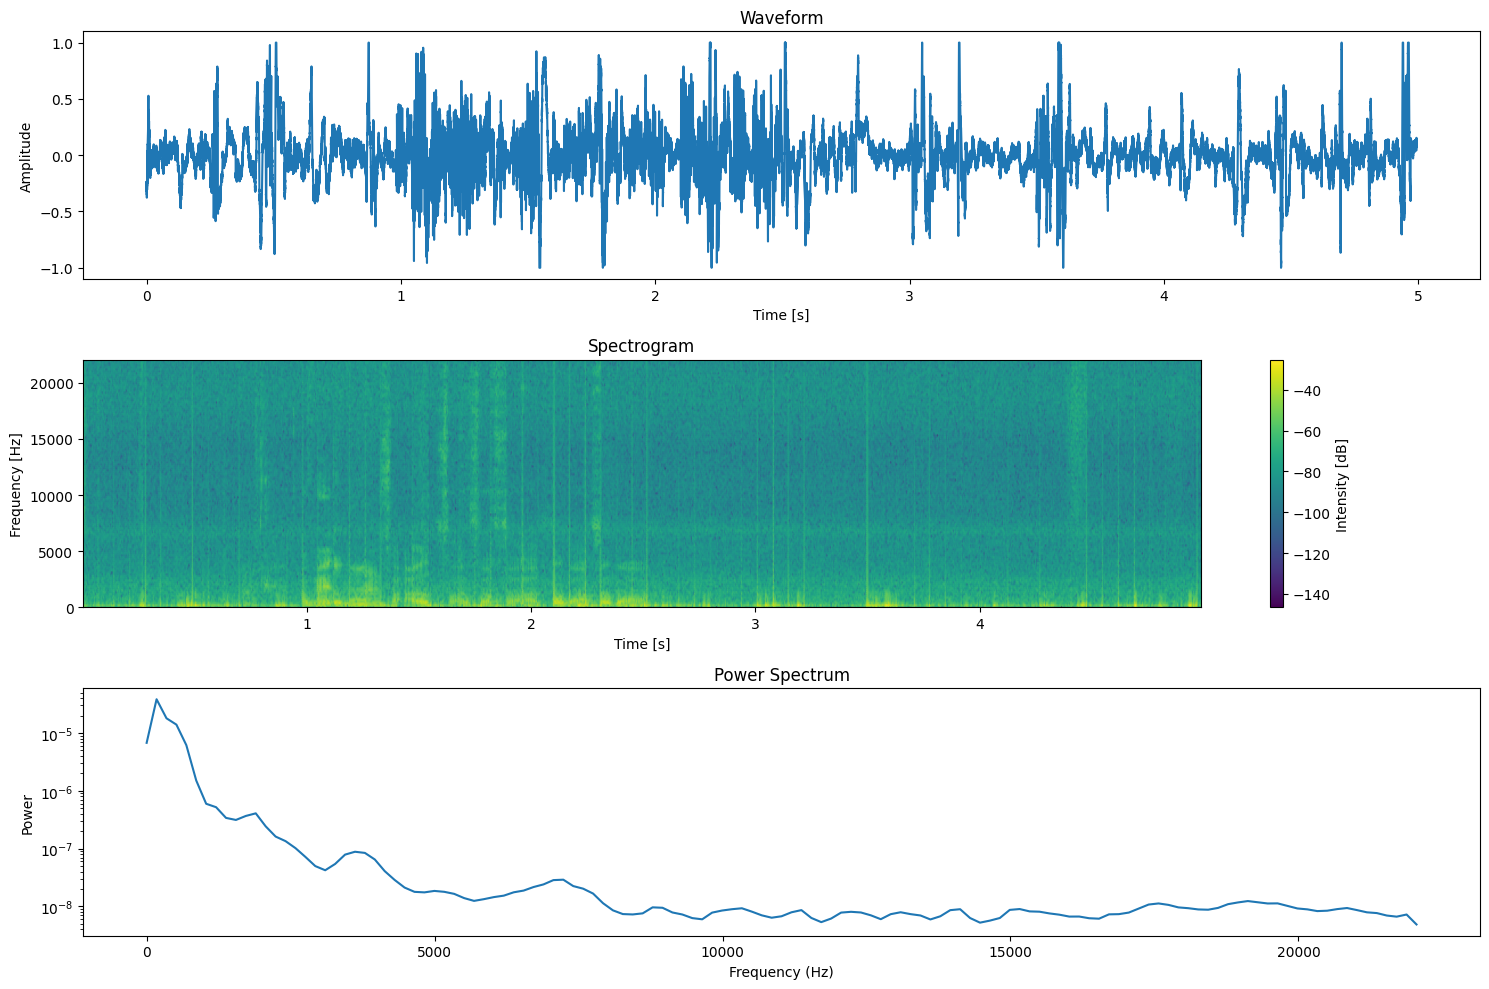

In [5]:
audio_path = 'audio_sources/recording_at_2025-10-20_16-47-07.wav'
plot_audio_analysis(audio_path)